In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [48]:
df = pd.read_csv('tweets.csv')

df.head()

,id,keyword,location,text,target
0,0,ablaze,NaN,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,1,ablaze,NaN,Telangana: Section 144 has been imposed in Bha...,1
2,2,ablaze,New York City,Arsonist sets cars ablaze at dealership https:...,1
3,3,ablaze,"Morgantown, WV",Arsonist sets cars ablaze at dealership https:...,1
4,4,ablaze,NaN,"""Lord Jesus, your love brings freedom and pard...",0


In [49]:
df.shape

(11370, 5)

In [50]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11370 entries, 0 to 11369
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   id        11370 non-null  int64
 1   keyword   11370 non-null  str  
 2   location  7952 non-null   str  
 3   text      11370 non-null  str  
 4   target    11370 non-null  int64
dtypes: int64(2), str(3)
memory usage: 444.3 KB


In [51]:
df.isnull().sum()

id             0
keyword        0
location    3418
text           0
target         0
dtype: int64

In [52]:
df = df[['keyword', 'text', 'target']].copy()

df.head()

,keyword,text,target
0,ablaze,"Communal violence in Bhainsa, Telangana. ""Ston...",1
1,ablaze,Telangana: Section 144 has been imposed in Bha...,1
2,ablaze,Arsonist sets cars ablaze at dealership https:...,1
3,ablaze,Arsonist sets cars ablaze at dealership https:...,1
4,ablaze,"""Lord Jesus, your love brings freedom and pard...",0


In [53]:
df['keyword'] = df['keyword'].fillna('')

df['text'] = df['text'].fillna('')

In [54]:
df.drop_duplicates(inplace=True)
df.shape

(11228, 3)

In [55]:
df['combined_text'] = df['keyword'] + " " + df['text']

df.head()

,keyword,text,target,combined_text
0,ablaze,"Communal violence in Bhainsa, Telangana. ""Ston...",1,"ablaze Communal violence in Bhainsa, Telangana..."
1,ablaze,Telangana: Section 144 has been imposed in Bha...,1,ablaze Telangana: Section 144 has been imposed...
2,ablaze,Arsonist sets cars ablaze at dealership https:...,1,ablaze Arsonist sets cars ablaze at dealership...
3,ablaze,Arsonist sets cars ablaze at dealership https:...,1,ablaze Arsonist sets cars ablaze at dealership...
4,ablaze,"""Lord Jesus, your love brings freedom and pard...",0,"ablaze ""Lord Jesus, your love brings freedom a..."


In [56]:
import re

def clean_text(text):

    # lowercase
    text = text.lower()

    # remove urls
    text = re.sub(r"http\S+", "", text)

    # remove mentions
    text = re.sub(r"@\w+", "", text)

    # remove hashtags
    text = re.sub(r"#", "", text)

    # remove special characters
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    return text

In [57]:
df['clean_text'] = df['combined_text'].apply(clean_text)

df.head()

,keyword,text,target,combined_text,clean_text
0,ablaze,"Communal violence in Bhainsa, Telangana. ""Ston...",1,"ablaze Communal violence in Bhainsa, Telangana...",ablaze communal violence in bhainsa telangana ...
1,ablaze,Telangana: Section 144 has been imposed in Bha...,1,ablaze Telangana: Section 144 has been imposed...,ablaze telangana section has been imposed in ...
2,ablaze,Arsonist sets cars ablaze at dealership https:...,1,ablaze Arsonist sets cars ablaze at dealership...,ablaze arsonist sets cars ablaze at dealership
3,ablaze,Arsonist sets cars ablaze at dealership https:...,1,ablaze Arsonist sets cars ablaze at dealership...,ablaze arsonist sets cars ablaze at dealership
4,ablaze,"""Lord Jesus, your love brings freedom and pard...",0,"ablaze ""Lord Jesus, your love brings freedom a...",ablaze lord jesus your love brings freedom and...


In [58]:
X = df['clean_text']

y = df['target']

In [59]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    stop_words='english',
    max_features=5000,
        ngram_range=(1,2)
)

X = tfidf.fit_transform(X)

print(X.shape)

(11228, 5000)


In [60]:
df.head()

,keyword,text,target,combined_text,clean_text
0,ablaze,"Communal violence in Bhainsa, Telangana. ""Ston...",1,"ablaze Communal violence in Bhainsa, Telangana...",ablaze communal violence in bhainsa telangana ...
1,ablaze,Telangana: Section 144 has been imposed in Bha...,1,ablaze Telangana: Section 144 has been imposed...,ablaze telangana section has been imposed in ...
2,ablaze,Arsonist sets cars ablaze at dealership https:...,1,ablaze Arsonist sets cars ablaze at dealership...,ablaze arsonist sets cars ablaze at dealership
3,ablaze,Arsonist sets cars ablaze at dealership https:...,1,ablaze Arsonist sets cars ablaze at dealership...,ablaze arsonist sets cars ablaze at dealership
4,ablaze,"""Lord Jesus, your love brings freedom and pard...",0,"ablaze ""Lord Jesus, your love brings freedom a...",ablaze lord jesus your love brings freedom and...


In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [62]:
from sklearn.linear_model import LogisticRegression

In [63]:
model = LogisticRegression(
    class_weight='balanced', 
    max_iter=1000
)

In [64]:
model.fit(X_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

In [65]:
pred = model.predict(X_test)

print(pred[:10])

[1 0 0 1 0 0 0 1 0 1]


In [66]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)

print("Accuracy:", accuracy)

Accuracy: 0.8437221727515584


In [67]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      0.88      0.90      1838
           1       0.56      0.70      0.62       408

    accuracy                           0.84      2246
   macro avg       0.74      0.79      0.76      2246
weighted avg       0.86      0.84      0.85      2246



In [68]:
sample = ["huge earthquake destroyed many buildings"]

sample_vector = tfidf.transform(sample)

result = model.predict(sample_vector)

print(result)

[1]


In [69]:
if result[0] == 1:
    print("Disaster Tweet")

else:
    print("Not Disaster Tweet")

Disaster Tweet


In [70]:
import pickle

with open("logistic_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("tfidf.pkl", "wb") as file:
    pickle.dump(tfidf, file)

print("Pickle files saved successfully")

Pickle files saved successfully


In [71]:
with open("logistic_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

with open("tfidf.pkl", "rb") as file:
    loaded_tfidf = pickle.load(file)

sample = ["flood destroyed roads"]

sample_vector = loaded_tfidf.transform(sample)

prediction = loaded_model.predict(sample_vector)

print(prediction)

[0]


In [72]:
import joblib

joblib.dump(model, "logistic_model.joblib")

joblib.dump(tfidf, "tfidf.joblib")

print("Joblib files saved successfully")

Joblib files saved successfully


In [73]:
loaded_model = joblib.load("logistic_model.joblib")

loaded_tfidf = joblib.load("tfidf.joblib")

sample = ["forest fire near city"]

sample_vector = loaded_tfidf.transform(sample)

prediction = loaded_model.predict(sample_vector)

print(prediction)

[1]


In [74]:
accuracy = accuracy_score(y_test, pred)
print("Accuracy:", accuracy)

Accuracy: 0.8437221727515584


In [75]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)

print(cm)

[[1611  227]
 [ 124  284]]


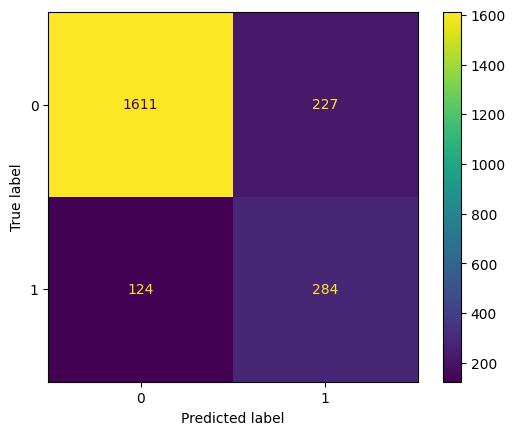

In [76]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, pred)

plt.show()

In [77]:
sample = ["forest fire near city"]

cleaned_sample = [clean_text(sample[0])]

sample_vector = loaded_tfidf.transform(cleaned_sample)

prediction = loaded_model.predict(sample_vector)

print(prediction)

[1]


In [78]:
train_score = model.score(X_train, y_train)
test_score = model.score(X_test, y_test)

print("Train Score:", train_score)
print("Test Score:", test_score)

Train Score: 0.9101536406145625
Test Score: 0.8437221727515584


In [79]:
probability = model.predict_proba(sample_vector)

print(probability)

[[0.31902106 0.68097894]]


In [84]:
samples = [
    "massive earthquake killed many people",
    "forest fire spreading rapidly",
    "flood water entered houses",
    "watching netflix today",
    "happy birthday friend",
    "cyclone approaching coast",
    "train accident injured passengers",
    "having dinner with family",
    "flood damages the roads and houses",
    "flood ruined the city drastically, please help us",
    "flood affects the building",
    "flood flood flood",
    "tsunami destroys the city"
]

sample_vector = tfidf.transform(samples)

predictions = model.predict(sample_vector)

probabilities = model.predict_proba(sample_vector)

for text, pred, prob in zip(samples, predictions, probabilities):

    if pred == 1:
        print(f"{text} --> Disaster ({prob[1]*100:.2f}%)")
    else:
        print(f"{text} --> Not Disaster ({prob[0]*100:.2f}%)")

massive earthquake killed many people --> Disaster (94.69%)
forest fire spreading rapidly --> Not Disaster (58.53%)
flood water entered houses --> Disaster (52.32%)
watching netflix today --> Not Disaster (73.98%)
happy birthday friend --> Not Disaster (83.71%)
cyclone approaching coast --> Not Disaster (58.02%)
train accident injured passengers --> Disaster (96.29%)
having dinner with family --> Not Disaster (70.85%)
flood damages the roads and houses --> Disaster (53.40%)
flood ruined the city drastically, please help us --> Not Disaster (74.26%)
flood affects the building --> Not Disaster (72.56%)
flood flood flood --> Not Disaster (73.92%)
tsunami destroys the city --> Disaster (52.32%)
